In [35]:
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_covtype
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

import torch._dynamo
import torch.utils.benchmark as benchmark
from torch.optim import Optimizer
from torchinfo import summary
from torch.autograd import Function
import torch._inductor.metrics as metrics

In [36]:
def zeropower_via_newtonschulz5(G: Tensor, steps: int) -> Tensor:
    assert G.ndim >= 2
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.clone().float()
    if G.size(-2) > G.size(-1):
        X = X.mT
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(-2) > G.size(-1):
        X = X.mT
    return X

class Muon(Optimizer):
    def __init__(self, params, lr=0.02, weight_decay=0.01, momentum=0.95, nesterov=True, ns_steps=5):
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            weight_decay = group["weight_decay"]
            momentum = group["momentum"]
            nesterov = group["nesterov"]
            ns_steps = group["ns_steps"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad.data

                if g.ndim < 2:
                    continue  # skip scalars, biases, etc.

                state = self.state[p]
                if "momentum_buffer" not in state:
                    state["momentum_buffer"] = torch.zeros_like(g)

                buf = state["momentum_buffer"]
                buf.mul_(momentum).add_(g)

                if nesterov:
                    g = g + momentum * buf
                else:
                    g = buf

                if g.ndim == 4:
                    g = g.view(g.size(0), -1)

                g = zeropower_via_newtonschulz5(g, steps=ns_steps).view_as(p)

                p.mul_(1 - lr * weight_decay)
                p.add_(g, alpha=-lr)

In [37]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")

In [38]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [ ]:
def train(model, criterion, optimizers, epochs):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    @torch._dynamo.explain
    def run_model(x):
        return model(x)

    print(run_model(X_train_tensor)) # type: ignore

    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    schedulers = [
        torch.optim.lr_scheduler.LinearLR(opt, start_factor=1.0, end_factor=0.05, total_iters=epochs)
        for opt in optimizers
    ]

    for epoch in range(1, epochs + 1):
        model.train()
        for opt in optimizers:
            opt.zero_grad()

        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()

        for opt in optimizers:
            opt.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        for scheduler in schedulers:
            scheduler.step()

        if epoch % 1 == 0:
            print(f"Epoch {epoch}/{epochs}, Train Loss: {train_loss.item():.32f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        print(f"[GPU] Peak memory allocated: {torch.cuda.max_memory_allocated() / 1024 ** 2:.2f} MB")
        print(f"[GPU] Peak memory reserved: {torch.cuda.max_memory_reserved() / 1024 ** 2:.2f} MB")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()  

In [ ]:
class StableNN(nn.Module):
    def __init__(self, n, num_layers=2):
        super().__init__()
        self.num_layers = num_layers
        self.initial_norm = nn.BatchNorm1d(n, affine=False, track_running_stats=True)

        self.blocks = nn.ModuleList()
        for i in range(num_layers):
            self.blocks.append(
                nn.Sequential(
                    nn.Linear(n + i, 1, bias=False),
                    nn.BatchNorm1d(1, affine=False, track_running_stats=True),
                    nn.ReLU(),
                    nn.BatchNorm1d(1, affine=False, track_running_stats=True),
                )
            )

        self.final_linear = nn.Linear(n + num_layers, 1, bias=True)
        self.final_norm = nn.BatchNorm1d(1, affine=True, track_running_stats=True)

    def forward(self, x):
        x = self.initial_norm(x)
        features = [x]

        for i in range(self.num_layers):
            inputs = torch.cat(features, dim=1)
            out = self.blocks[i](inputs)
            features.append(out)

        final_input = torch.cat(features, dim=1)
        out = self.final_linear(final_input)
        out = self.final_norm(out)
        return torch.cat([out, -out], dim=1)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─ModuleList: 2-2                   --                        --
│    │    └─Sequential: 3-1              [43152, 1]                7
│    └─Linear: 2-3                       [43152, 1]                9
│    └─BatchNorm1d: 2-4                  [43152, 1]                2
Total params: 18
Trainable params: 18
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.78
Input size (MB): 1.21
Forward/backward pass size (MB): 1.04
Params size (MB): 0.00
Estimated Total Size (MB): 2.24
_orig_mod.blocks.0.0.weight
Parameter containing:
tensor([[-0.2438,  0.2500, -0.3350,  0.2883,  0.2894, -0.1752, -0.2910]],
       requires_grad=True)
_orig_mod.final_linear.weight
Parameter containing:
tensor([[-0.0705, 

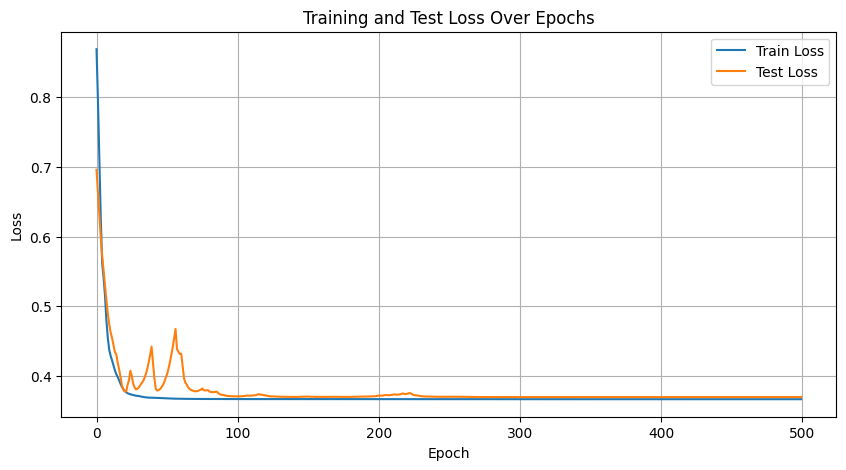

_orig_mod.blocks.0.0.weight
Parameter containing:
tensor([[-0.1199,  3.6511, -0.3328, -0.0878,  0.5211,  0.1630, -0.5480]],
       requires_grad=True)
_orig_mod.final_linear.weight
Parameter containing:
tensor([[ 0.1463, -0.2352,  0.4539, -0.0726, -0.0728, -0.0101,  0.0245,  0.4904]],
       requires_grad=True)
_orig_mod.final_linear.bias
Parameter containing:
tensor([-0.1560], requires_grad=True)
_orig_mod.final_norm.weight
Parameter containing:
tensor([1.5752], requires_grad=True)
_orig_mod.final_norm.bias
Parameter containing:
tensor([0.5876], requires_grad=True)


In [ ]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=1).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf)) # type: ignore
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─ModuleList: 2-47                  --                        (recursive)
│    │    └─Linear: 3-1                  [43152, 1]                7
│    └─ModuleList: 2-48                  --                        --
│    │    └─BatchNorm1d: 3-2             [43152, 1]                --
│    └─ModuleList: 2-49                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─ModuleList: 2-47                  --                        (recursive)
│    │    └─Linear: 3-4                  [43152, 1]                8
│    └─ModuleList: 2-48                  --                        --
│    │    └─BatchNorm1d: 3-5             [43152, 1]                --

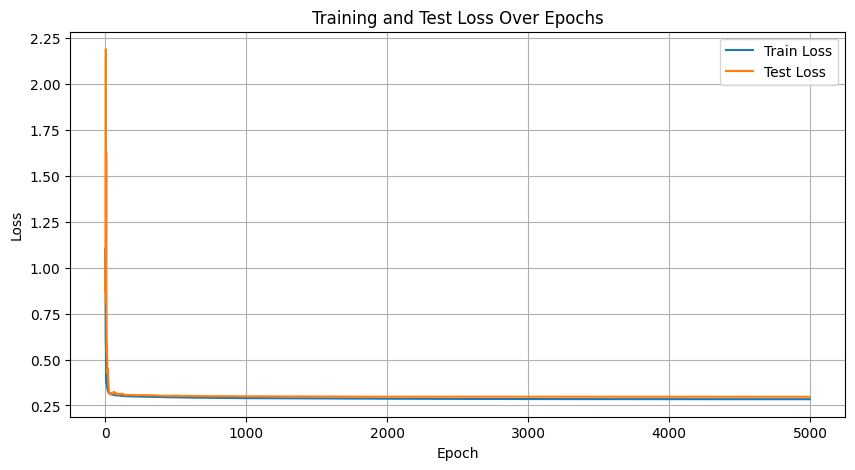

_orig_mod.linears.0.weight
Parameter containing:
tensor([[-2.6068, -1.5826, -6.9374,  3.8998, -1.9069,  0.0803, -1.8155]],
       requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 0.2802, 29.2523,  2.7279,  0.3910, -3.1444,  0.7078,  0.5437,  1.2126]],
       requires_grad=True)
_orig_mod.linears.2.weight
Parameter containing:
tensor([[  1.6403,   6.6199,   3.8223,  -6.0363, -21.6321,  13.8497,  -3.4239,
           8.2441,  -2.8009]], requires_grad=True)
_orig_mod.linears.3.weight
Parameter containing:
tensor([[  2.6290,   1.4012,   3.6727,  -0.0638,  32.2505, -28.8333,  -0.8341,
           0.1797,  -2.4162,  -3.6152]], requires_grad=True)
_orig_mod.linears.4.weight
Parameter containing:
tensor([[  0.6127,  -4.8258,   5.0279,  -1.5420,  -1.8252,  11.7099,   6.9762,
           0.3937,  10.7094,   5.8140, -13.1410]], requires_grad=True)
_orig_mod.linears.5.weight
Parameter containing:
tensor([[-1.6468, -7.2674,  8.1806, -1.9849,  2.3910,  3.4229,  1.8774,  8.

In [20]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=16).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.01, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf)) # type: ignore
    # optim.Adam(model.parameters()), # type: ignore
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─ModuleList: 2-47                  --                        (recursive)
│    │    └─Linear: 3-1                  [43152, 1]                7
│    └─ModuleList: 2-48                  --                        --
│    │    └─BatchNorm1d: 3-2             [43152, 1]                --
│    └─ModuleList: 2-49                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─ModuleList: 2-47                  --                        (recursive)
│    │    └─Linear: 3-4                  [43152, 1]                8
│    └─ModuleList: 2-48                  --                        --
│    │    └─BatchNorm1d: 3-5             [43152, 1]                --

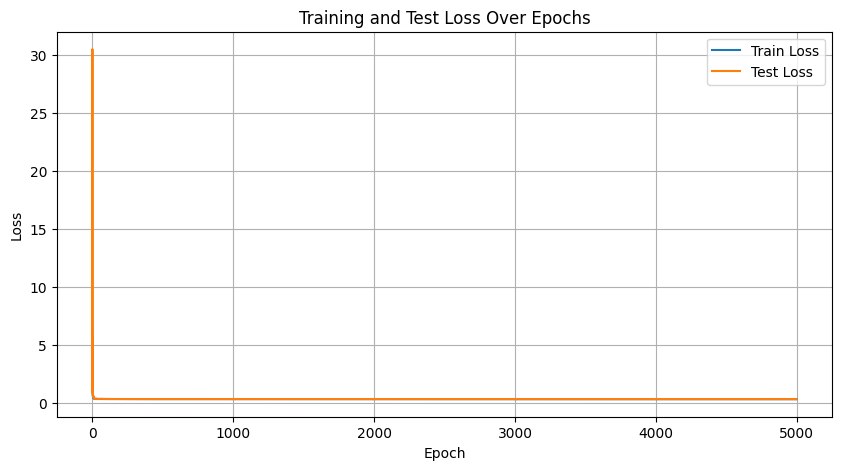

_orig_mod.linears.0.weight
Parameter containing:
tensor([[  8.7175,   0.9923,   0.8566,  -3.6109, -10.8801,   4.7271,  -1.1814]],
       requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[-0.8890, -1.3728, 16.8716,  0.1951,  0.1889,  1.7622, -0.1310,  0.7611]],
       requires_grad=True)
_orig_mod.linears.2.weight
Parameter containing:
tensor([[ 3.2975,  7.1130, 11.3755, -0.2282, -6.4736,  2.2732,  0.2971,  0.3419,
          1.9461]], requires_grad=True)
_orig_mod.linears.3.weight
Parameter containing:
tensor([[-0.7415,  0.3695, 27.7357,  0.4230,  4.5023,  0.0779,  0.6735,  2.3187,
          2.6308, -3.9230]], requires_grad=True)
_orig_mod.linears.4.weight
Parameter containing:
tensor([[ 2.8999, -2.3514,  9.2065, -0.0304,  0.1892, -3.7574, -0.1101, -1.2623,
         -0.3458, -1.8796, -4.1815]], requires_grad=True)
_orig_mod.linears.5.weight
Parameter containing:
tensor([[ -4.8462,  -7.9248,  -3.1817,   0.4294,  -7.2724,  11.5566,  -0.6484,
           2.6389, 

In [13]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=16).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=1.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf)) # type: ignore
    # optim.Adam(model.parameters()), # type: ignore
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
StableNN                                 [43152, 2]                --
├─CReLU: 1-1                             [43152, 14]               --
├─ModuleList: 1-62                       --                        --
│    └─BatchNorm1d: 2-1                  [43152, 14]               --
├─ModuleList: 1-63                       --                        (recursive)
│    └─Linear: 2-2                       [43152, 1]                14
├─ModuleList: 1-64                       --                        (recursive)
│    └─BatchNorm1d: 2-3                  [43152, 1]                --
├─CReLU: 1-5                             [43152, 16]               --
├─ModuleList: 1-62                       --                        --
│    └─BatchNorm1d: 2-4                  [43152, 16]               --
├─ModuleList: 1-63                       --                        (recursive)
│    └─Linear: 2-5                       [43152, 1]       

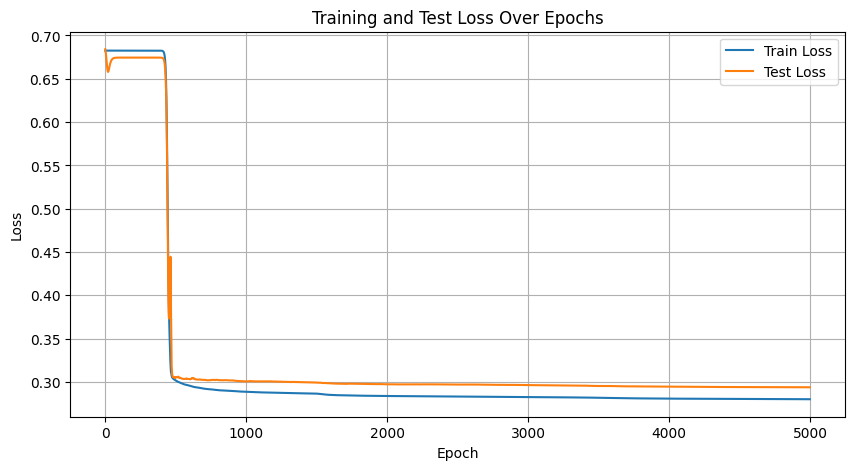

linears.0.weight
Parameter containing:
tensor([[-0.0483,  0.1500,  0.2335, -0.0914,  0.1119,  0.1700, -0.1932, -0.2370,
         -0.0476,  0.0067,  0.1481,  0.2258, -0.2446,  0.1442]],
       requires_grad=True)
linears.1.weight
Parameter containing:
tensor([[ 0.1952, -0.3132,  0.0957,  0.0805,  0.1759,  0.1394, -0.1345, -0.2362,
          0.1448, -0.0137, -0.0276, -0.2026,  0.0153,  0.0156,  0.2013, -0.1432]],
       requires_grad=True)
linears.2.weight
Parameter containing:
tensor([[-0.0851,  0.0631,  0.0045,  0.0029,  0.0264,  0.0054,  0.1342, -0.1743,
         -0.1580, -0.1627,  0.0940, -0.1545,  0.0860,  0.0068, -0.0727,  0.0808,
         -0.1565, -0.0795]], requires_grad=True)
linears.3.weight
Parameter containing:
tensor([[ 0.2226, -0.1087,  0.2986, -0.0347,  0.1970, -0.0771, -0.2000,  0.0320,
         -0.1014,  0.0939,  0.1535, -0.0724, -0.1711, -0.0456, -0.1103,  0.1631,
         -0.0757,  0.1193,  0.1302, -0.0934]], requires_grad=True)
linears.4.weight
Parameter containing:
t

In [ ]:
model = (StableNN(n=X.shape[1], num_layers=16).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=1.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf)) # type: ignore
    # optim.Adam(model.parameters()), # type: ignore
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 7])
torch.Size([2, 28])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─ModuleList: 2-1                   --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 7]                --
│    └─ModuleList: 2-2                   --                        --
│    │    └─Linear: 3-2                  [43152, 7]                49
│    └─ModuleList: 2-3                   --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─CReLU: 2-4                        [43152, 28]               --
│    └─BatchNorm1d: 2-5                  [43152, 28]               --
│    └─Linear: 2-6                       [43152, 2]                58
Total params: 107
Trainable params: 107
Non-trainable params: 0


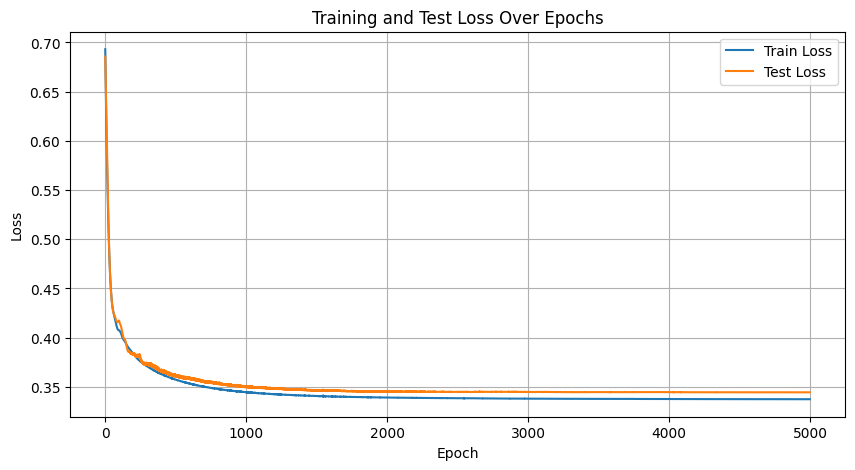

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 1.5887,  0.2304, -0.1467, -0.0643,  0.5939,  0.1285, -1.6730],
        [ 1.3144,  1.0672, -0.0395,  0.2786, -0.7108,  4.6172, -4.8481],
        [ 1.8673, -0.1380,  1.0715, -0.4315, -1.8703,  0.6759,  0.1009],
        [ 2.0265,  0.6595, -0.0611,  0.4622, -2.9935,  2.7253, -1.1992],
        [-1.3264, -0.7468,  0.3235, -0.2035, -2.5234, -2.0103,  6.9526],
        [ 0.0460,  1.0269, -0.0155, -0.2034,  1.8896,  6.1569, -6.6462],
        [ 2.3786, -0.3640,  0.2131, -0.3832, -0.1509, -0.6722,  1.2013]],
       requires_grad=True)
_orig_mod.final_linear.weight
Parameter containing:
tensor([[ 0.6049,  0.8582,  1.3887, -0.1150,  0.5251,  0.3981, -0.2058, -0.0749,
          2.7477,  0.3255, -1.7550, -0.7960, -1.5286, -0.5167,  0.3326,  0.1499,
          0.1112,  0.4290, -0.1549,  1.1654, -0.0735, -0.7421,  3.5960, -0.5562,
         -1.4425, -0.2657, -1.3308, -0.8161],
        [-0.6014, -0.8536, -1.3784,  0.1153, -0.5247, -0.3995,  0.2079,

In [31]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=1).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 7])
torch.Size([28, 28])
torch.Size([2, 112])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─ModuleList: 2-5                   --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 7]                --
│    └─ModuleList: 2-6                   --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                49
│    └─ModuleList: 2-7                   --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─CReLU: 2-4                        [43152, 28]               --
│    └─ModuleList: 2-5                   --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 28]               --
│    └─ModuleList: 2-6           

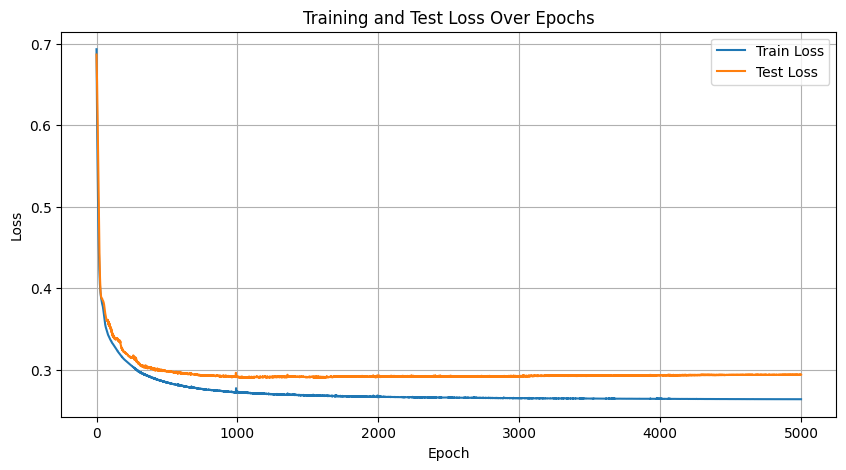

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.5579,  1.4888,  1.1980, -0.0561, -1.9264,  1.8688, -0.6410],
        [ 0.0535,  0.1276, -0.0040, -0.0052, -2.4657,  2.6458, -0.1616],
        [ 1.1173,  0.5117,  0.7210, -0.2283,  0.3296, -0.6413, -0.2060],
        [-0.1099, -0.0759,  1.9709,  0.6813, -2.3357,  2.0978,  0.3135],
        [-1.5670, -0.7162,  0.4390,  0.2978,  1.6124, -1.8091,  2.7501],
        [ 1.0176,  1.3103,  0.7458, -0.6296,  0.9367,  2.8653, -2.8644],
        [ 1.9747, -0.1371,  1.4561, -0.8768, -0.8541, -1.4799,  1.3878]],
       requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 1.0060e-01,  1.1485e+00,  1.0989e-01, -5.3687e-02,  6.2346e-01,
          1.1139e+00, -4.6371e-01,  3.7130e-02,  1.3637e+00, -7.7381e-01,
         -1.3255e-01,  1.6756e-01,  4.4997e-01,  7.2830e-01,  1.9419e-01,
          4.8595e-01, -5.0131e-01,  1.3976e-01,  4.0170e-01,  4.4201e-01,
         -5.5603e-01, -4.1038e-01,  8.4748e-02,  5.6877e-01, -6.241

In [30]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=2).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([14, 14])
torch.Size([56, 56])
torch.Size([2, 224])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-7                   --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-8                   --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 14]               196
│    └─ModuleList: 2-9                   --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 14]               --
│    └─CReLU: 2-6                        [43152, 56]               --
│    └─ModuleList: 2-7        

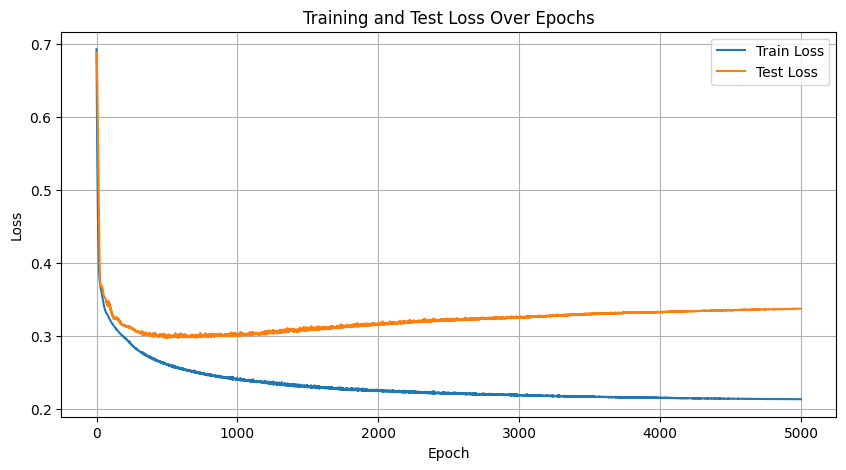

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 2.0876e+00,  4.2091e-01,  1.1364e+00,  2.0084e-01, -1.4022e+00,
         -8.6586e-01,  4.6240e-01, -2.5030e+00,  9.5249e-02,  7.9517e-04,
          1.3333e+00, -7.1721e-01,  3.1602e+00, -1.4033e+00],
        [ 1.8820e+00,  1.2535e+00,  2.1297e-01,  5.9550e-01, -8.4601e-01,
         -1.0963e-01, -4.6018e-01, -4.5005e-01,  6.6326e-01,  2.2434e-02,
          2.3425e-01,  3.1094e+00, -1.8307e+00, -1.0850e+00],
        [-3.4782e-01,  1.0805e+00,  8.1607e-01,  1.9308e-01,  1.2531e-01,
         -8.8545e-02,  8.1931e-01, -5.2849e-01,  5.5647e-01, -1.0469e+00,
          4.5751e-02,  7.6379e-01, -1.5399e+00,  1.2575e+00],
        [ 4.4227e-01,  9.9635e-01,  1.5807e-01,  1.8396e+00, -1.8061e+00,
          1.4668e-01,  1.5285e+00,  1.3384e+00,  3.7397e-01, -5.7581e-01,
         -4.4142e-01, -4.7339e-01,  2.3928e-01,  7.6240e-02],
        [-7.3370e-01,  2.6052e-01,  1.2396e-02,  9.1133e-02,  3.1363e+00,
         -2.1423e+00, -3.2920e-01, -1

In [28]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=2).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [15]:
model = (StableNN(n=X.shape[1], num_layers=2).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([14, 14])
torch.Size([56, 56])
torch.Size([2, 224])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
StableNN                                 [43152, 2]                --
├─BatchNorm1d: 1-1                       [43152, 7]                --
├─CReLU: 1-2                             [43152, 14]               --
├─ModuleList: 1-7                        --                        --
│    └─BatchNorm1d: 2-1                  [43152, 14]               --
├─ModuleList: 1-8                        --                        (recursive)
│    └─Linear: 2-2                       [43152, 14]               196
├─ModuleList: 1-9                        --                        --
│    └─BatchNorm1d: 2-3                  [43152, 14]               --
├─CReLU: 1-6                             [43152, 56]               --
├─ModuleList: 1-7                        --                        --
│    └─BatchNorm1d: 2-4       

KeyboardInterrupt: 